# Previsão do valor de veículos com base na Tabela FIPE

## 1. Identificação e descrição do problema

| | |
|---|---|
| **Título** | Previsão do valor de veículos com base no histórico da Tabela FIPE (2001–2022) |
| **Integrantes** | Danillo Matos Garcez · Luciano Davi Martins de Santana Silva · Nicolas de Carvalho Lessa |
| **Fonte dos dados** | [Tabela Fipe — Kaggle (`franckepeixoto/tabela-fipe`)](https://www.kaggle.com/datasets/franckepeixoto/tabela-fipe) |
| **Atributo-alvo** | `valor` — preço médio de mercado do veículo, em reais (R$) |
| **Atributos preditivos** | `marca`, `modelo`, `anoModelo`, `mesReferencia`, `anoReferencia` — e atributos derivados deles (como a idade do veículo na data de referência), criados no pré-processamento |
| **Tipo da tarefa** | **Regressão** |

**Objetivo.** A Tabela FIPE é a principal referência de preços médios de veículos no Brasil, publicada
mensalmente e usada em negociações, seguros e financiamentos. Este trabalho constrói um modelo de
**regressão** capaz de estimar o valor FIPE de um veículo a partir de suas características (marca,
modelo, ano do modelo) e da data de referência (mês/ano da publicação). Com isso, é possível estimar
quanto um determinado carro valia — ou valeria — em um mês/ano dentro do período coberto pelos dados,
e analisar como os preços evoluem com a idade do veículo e com o tempo.

**Por que regressão?** O atributo-alvo (`valor`) é um número **contínuo** em reais, e não uma
categoria. O interesse é prever a magnitude do preço, portanto a tarefa é de regressão; classificação
só seria adequada se o alvo fosse discreto (ex.: faixas de preço).


## 2. Configuração do ambiente e obtenção dos dados

O notebook foi preparado para executar no **Google Colab** sem nenhum arquivo local: os dados são
baixados diretamente do Kaggle (fonte pública) por meio da biblioteca `kagglehub`, que não exige
credenciais para datasets públicos. As demais bibliotecas (pandas, NumPy, Matplotlib, scikit-learn)
já fazem parte do ambiente padrão do Colab.


In [3]:
# No Google Colab, apenas o kagglehub precisa ser instalado.
%pip install -q kagglehub


Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paleta e estilo únicos para todos os gráficos do notebook
AZUL        = "#2a78d6"   # cor principal (série única / magnitude)
TINTA       = "#0b0b0b"   # texto principal
TINTA_SEC   = "#52514e"   # rótulos de eixo
CINZA_EIXO  = "#898781"
CINZA_GRADE = "#e1e0d9"
SUPERFICIE  = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE,
    "axes.facecolor":   SUPERFICIE,
    "axes.edgecolor":   "#c3c2b7",
    "axes.grid": True,
    "grid.color": CINZA_GRADE,
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "text.color": TINTA,
    "axes.labelcolor": TINTA_SEC,
    "axes.titlecolor": TINTA,
    "xtick.color": CINZA_EIXO,
    "ytick.color": CINZA_EIXO,
    "font.size": 11,
})

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")


ModuleNotFoundError: No module named 'matplotlib'

### 2.1 Download do dataset

O `kagglehub` baixa a versão mais recente do dataset e a mantém em cache local, portanto reexecutar a
célula não repete o download.


In [ ]:
import kagglehub

caminho = kagglehub.dataset_download("franckepeixoto/tabela-fipe")
df = pd.read_csv(f"{caminho}/tabela-fipe-historico-precos.csv")

print(f"Registros: {df.shape[0]:,}".replace(",", "."))
print(f"Atributos: {df.shape[1]}")


Registros: 466.020
Atributos: 8


## 3. Compreensão dos dados

Nesta seção examinamos a estrutura do conjunto de dados: o que cada coluna significa, os tipos das
variáveis, valores ausentes, duplicações, inconsistências e a distribuição do atributo-alvo.

### 3.1 Estrutura geral


In [ ]:
df.head(10)

,Unnamed: 0,codigoFipe,marca,modelo,anoModelo,mesReferencia,anoReferencia,valor
0,0,038003-2,Acura,Integra GS 1.8,1992,11,2016,"13,041.00"
1,1,038001-6,Acura,NSX 3.0,1995,3,2013,"52,339.00"
2,2,038003-2,Acura,Integra GS 1.8,1992,3,2018,"12,423.00"
3,3,038002-4,Acura,Legend 3.2/3.5,1998,5,2016,"31,067.00"
4,4,038002-4,Acura,Legend 3.2/3.5,1998,2,2019,"26,381.00"
5,5,038002-4,Acura,Legend 3.2/3.5,1998,9,2015,"29,124.00"
6,6,038001-6,Acura,NSX 3.0,1995,10,2018,"43,081.00"
7,7,038003-2,Acura,Integra GS 1.8,1992,10,2019,"11,433.00"
8,8,038002-4,Acura,Legend 3.2/3.5,1998,5,2017,"29,258.00"
9,9,038001-6,Acura,NSX 3.0,1995,10,2013,"51,758.00"


Cada linha do dataset é **um preço de referência**: o valor médio de mercado de um veículo
(identificado por `codigoFipe` + `anoModelo`) publicado pela FIPE em um determinado mês/ano de
referência. O mesmo carro aparece, portanto, em várias linhas — uma para cada mês em que foi avaliado.

**Dicionário de dados:**

| Coluna | Significado |
|---|---|
| `Unnamed: 0` | Índice sequencial residual da exportação do CSV — não carrega informação e será descartado |
| `codigoFipe` | Código único do modelo na Tabela FIPE (ex.: `025145-3`) |
| `marca` | Fabricante do veículo |
| `modelo` | Descrição textual do modelo e da versão |
| `anoModelo` | Ano do modelo do veículo |
| `mesReferencia` | Mês da tabela de referência publicada pela FIPE (1–12) |
| `anoReferencia` | Ano da tabela de referência (2001–2022) |
| `valor` | **(alvo)** Preço médio de mercado em reais na data de referência |


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 466020 entries, 0 to 466019
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Unnamed: 0     466020 non-null  int64  
 1   codigoFipe     466020 non-null  str    
 2   marca          466020 non-null  str    
 3   modelo         466020 non-null  str    
 4   anoModelo      466020 non-null  int64  
 5   mesReferencia  466020 non-null  int64  
 6   anoReferencia  466020 non-null  int64  
 7   valor          466020 non-null  float64
dtypes: float64(1), int64(4), str(3)
memory usage: 28.4 MB


**Interpretação.** São **466.020 registros e 8 colunas**, sem nenhum valor nulo em nenhuma coluna —
algo esperado, já que os dados vêm de raspagem direta das tabelas oficiais da FIPE, que são completas
por construção. Os tipos estão adequados: três colunas de texto (`codigoFipe`, `marca`, `modelo`),
quatro inteiras (índice residual, `anoModelo`, `mesReferencia`, `anoReferencia`) e o alvo `valor` como
número real. Nenhuma conversão de tipo será necessária; o pré-processamento poderá se concentrar em
conteúdo, não em formato.


In [ ]:
display(df.describe(include="number").T)

print("Cardinalidade dos atributos de texto:")
print(df[["codigoFipe", "marca", "modelo"]].nunique().to_string())


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,"466,020.00","272,398.09","159,700.92",0.00,"132,377.00","275,044.50","408,696.25","544,151.00"
anoModelo,"466,020.00","2,008.97",10.00,"1,985.00","2,000.00","2,009.00","2,020.00","2,023.00"
mesReferencia,"466,020.00",6.45,3.42,1.00,4.00,6.00,9.00,12.00
anoReferencia,"466,020.00","2,015.18",5.68,"2,001.00","2,011.00","2,017.00","2,020.00","2,022.00"
valor,"466,020.00","115,745.60","325,073.71","1,871.00","19,388.00","39,416.50","84,794.50","8,407,082.00"


Cardinalidade dos atributos de texto:
codigoFipe    5283
marca           84
modelo        5366


**Interpretação.**

- **`valor` (alvo):** a média (≈ R$ 115,7 mil) é quase o triplo da mediana (≈ R$ 39,4 mil) e o máximo
  chega a R$ 8,4 milhões — forte **assimetria à direita**: poucos veículos de luxo puxam a média para
  cima. A distribuição será examinada em detalhe na seção 3.4.
- **`anoModelo`** vai de 1985 a 2023 e **`anoReferencia`** de 2001 a 2022 — há preços de modelo de ano
  *seguinte* ao da referência (lançamentos), o que é normal no mercado; valores além disso são
  investigados na seção 3.3.
- **Cardinalidade:** são **84 marcas**, mas **5.366 modelos** e **5.283 códigos FIPE**. A cardinalidade
  altíssima de `modelo` orienta o pré-processamento: one-hot encoding é viável para `marca`, mas não
  para `modelo`/`codigoFipe`, que exigirão outra estratégia de codificação.
- Há **mais modelos (5.366) do que códigos FIPE (5.283)** — indício de grafias diferentes para o mesmo
  carro, confirmado na seção seguinte.


### 3.2 Valores ausentes e duplicações

Além de duplicatas exatas (linha inteira repetida), procuramos **duplicatas lógicas**: o mesmo veículo
(`codigoFipe` + `anoModelo`) avaliado duas vezes na mesma referência (`mesReferencia` +
`anoReferencia`), o que não deveria acontecer.


In [ ]:
print("Valores ausentes por coluna:")
print(df.isna().sum().to_string())

print(f"\nLinhas duplicadas (todas as colunas): {df.duplicated().sum()}")

chave = ["codigoFipe", "anoModelo", "mesReferencia", "anoReferencia"]
dup_logicas = df[df.duplicated(subset=chave, keep=False)]
print(f"Duplicatas lógicas (mesma chave {chave}): {len(dup_logicas)} linhas")
dup_logicas.sort_values(chave)


Valores ausentes por coluna:


Unnamed: 0       0
codigoFipe       0
marca            0
modelo           0
anoModelo        0
mesReferencia    0
anoReferencia    0
valor            0



Linhas duplicadas (todas as colunas): 0
Duplicatas lógicas (mesma chave ['codigoFipe', 'anoModelo', 'mesReferencia', 'anoReferencia']): 4 linhas


,Unnamed: 0,codigoFipe,marca,modelo,anoModelo,mesReferencia,anoReferencia,valor
187001,214807,033182-1,Land Rover,Range.R. Sp.HSE Dyn.Bi. 2.0 Si4(Hibrido),2022,11,2021,"678,821.00"
187828,216354,033182-1,Land Rover,Range.R. SP.HSE Dyn.BL. 2.0 Si4(Hibrido),2022,11,2021,"678,821.00"
365389,425809,087007-2,Rolls-Royce,CullinanBlack Badged 6.7 V12 Aut.,2022,11,2021,"6,802,120.00"
365405,425825,087007-2,Rolls-Royce,Cullinan Black Badge 6.7 V12 Aut.,2022,11,2021,"6,802,120.00"


**Interpretação.** Não há valores ausentes nem linhas integralmente duplicadas. Existem apenas **2
pares de duplicatas lógicas** (4 linhas): em ambos, o mesmo veículo aparece duas vezes na referência
de nov/2021 com o **mesmo valor**, mas com grafias levemente diferentes do modelo (ex.: *"Cullinan
Black Badge"* × *"CullinanBlack Badged"*). Isso confirma que o campo `modelo` contém inconsistências
de digitação da fonte, e que **`codigoFipe` é o identificador confiável** do veículo. O tratamento
(manter uma linha de cada par) será feito no pré-processamento.


### 3.3 Inconsistências: o código `anoModelo = 2022`

No mercado é normal um modelo do ano seguinte ao da referência (lançamento). Suspeito é um
`anoModelo` **mais de um ano à frente** da referência — um "carro do futuro". Verificamos quantos
registros estão nessa situação e qual padrão eles seguem.


In [ ]:
impossiveis = df[df["anoModelo"] > df["anoReferencia"] + 1]
print(f"Registros com anoModelo > anoReferencia + 1: {len(impossiveis):,}".replace(",", "."))
print("\nAno do modelo nesses registros:")
print(impossiveis["anoModelo"].value_counts().to_string())

# Exemplo concreto: Renault Sandero "anoModelo 2022" avaliado em outubro de 2009
exemplo = df[(df["codigoFipe"] == "025145-3") & (df["anoReferencia"] == 2009) & (df["mesReferencia"] == 10)]
exemplo[["marca", "modelo", "anoModelo", "mesReferencia", "anoReferencia", "valor"]]


Registros com anoModelo > anoReferencia + 1: 102.261

Ano do modelo nesses registros:
anoModelo
2022    102261


,marca,modelo,anoModelo,mesReferencia,anoReferencia,valor
322253,Renault,SANDERO Privilège Hi-Flex 1.6 8V 5p,2022,10,2009,"40,519.00"


**Interpretação.** Há **102.261 registros** "impossíveis" — e **todos, sem exceção, têm
`anoModelo = 2022`**. O padrão revela a causa: na Tabela FIPE original, veículo **zero km** é
codificado com ano `32000`, e o autor do dataset converteu esse código para `2022` (ano da coleta dos
dados). O exemplo acima confirma: um "Sandero anoModelo 2022" avaliado em out/2009 por R$ 40.519 é,
na verdade, **o preço do Sandero zero km em outubro de 2009** — compatível com o preço de tabela de um
Sandero novo naquela época, e absurdo para um modelo 2022.

Consequências para o trabalho:

1. `anoModelo = 2022` significa, na prática, **"veículo zero km na data de referência"**;
2. apenas nas referências de 2021–2022 (12.610 registros) o valor `2022` poderia ser de fato um modelo
   2022 usado — uma ambiguidade inerente à codificação da fonte, que registraremos como limitação;
3. no pré-processamento criaremos um atributo binário `zero_km` e definiremos a idade do veículo como
   0 nesses casos, em vez de calcular `anoReferencia − anoModelo` (que daria idades negativas absurdas,
   como −13).


### 3.4 Distribuição do atributo-alvo

Como o alvo é o preço em reais, examinamos sua distribuição na escala original e na escala
logarítmica (log10).


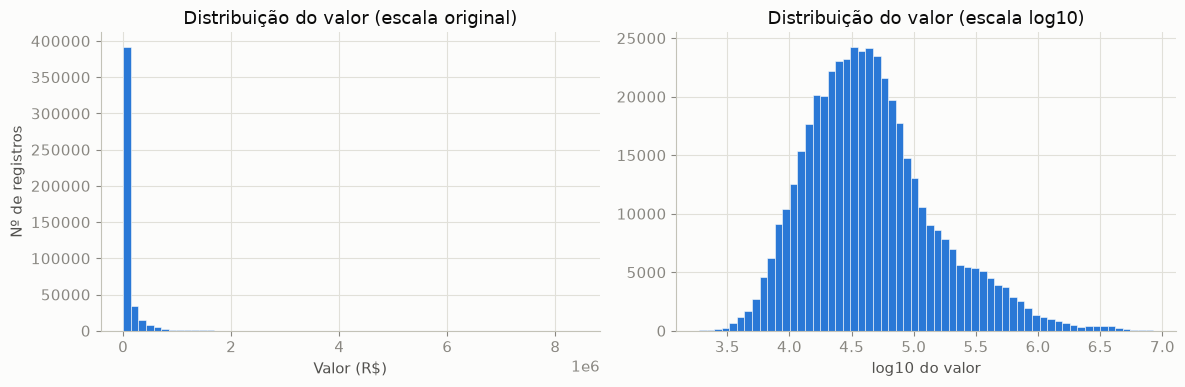

Média:    R$      115.746
Mediana:  R$       39.416
Máximo:   R$    8.407.082
Assimetria (skew): 9.9


In [ ]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))

eixos[0].hist(df["valor"], bins=60, color=AZUL, edgecolor=SUPERFICIE, linewidth=0.4)
eixos[0].set_title("Distribuição do valor (escala original)")
eixos[0].set_xlabel("Valor (R$)")
eixos[0].set_ylabel("Nº de registros")

eixos[1].hist(np.log10(df["valor"]), bins=60, color=AZUL, edgecolor=SUPERFICIE, linewidth=0.4)
eixos[1].set_title("Distribuição do valor (escala log10)")
eixos[1].set_xlabel("log10 do valor")

plt.tight_layout()
plt.show()

print("Média:    R$ " + f"{df['valor'].mean():>12,.0f}".replace(",", "."))
print("Mediana:  R$ " + f"{df['valor'].median():>12,.0f}".replace(",", "."))
print("Máximo:   R$ " + f"{df['valor'].max():>12,.0f}".replace(",", "."))
print(f"Assimetria (skew): {df['valor'].skew():.1f}")


**Interpretação.** Na escala original (esquerda) a distribuição é **fortemente assimétrica à
direita**: a grande maioria dos veículos vale menos de R$ 100 mil, mas a cauda se estende até
R$ 8,4 milhões (superesportivos e carros de luxo, como o Rolls-Royce Cullinan visto na seção 3.2).
O coeficiente de assimetria impresso acima confirma numericamente o que o gráfico mostra.

Já em **escala logarítmica** (direita) a distribuição fica aproximadamente simétrica, em forma de
sino. Isso tem duas implicações práticas:

1. métricas quadráticas como o RMSE serão **dominadas pelos veículos caros** — algo a considerar na
   avaliação dos modelos;
2. uma **transformação logarítmica do alvo** é uma candidata natural no pré-processamento,
   especialmente para a regressão linear, que assume relação aditiva entre atributos e alvo.


### 3.5 Cobertura temporal dos dados

Por fim, verificamos como os registros se distribuem ao longo dos anos de referência — o
"desbalanceamento" possível em um problema de regressão como este não é de classes (não há classes),
mas de **representatividade das regiões do espaço de entrada**, em particular do tempo.


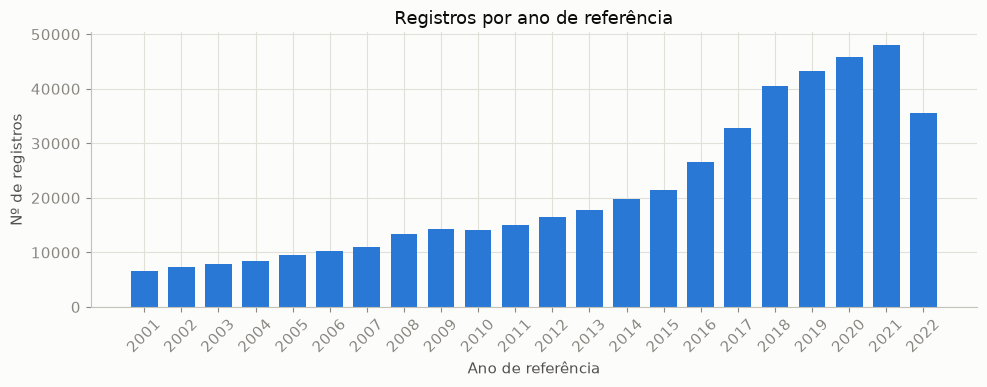

Meses cobertos em 2022: [1, 2, 3, 4, 5, 6, 7, 8]


In [ ]:
contagem_ano = df["anoReferencia"].value_counts().sort_index()

fig, eixo = plt.subplots(figsize=(10, 4))
eixo.bar(contagem_ano.index, contagem_ano.values, width=0.72, color=AZUL)
eixo.set_title("Registros por ano de referência")
eixo.set_xlabel("Ano de referência")
eixo.set_ylabel("Nº de registros")
eixo.set_xticks(contagem_ano.index)
eixo.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("Meses cobertos em 2022:", sorted(df.loc[df["anoReferencia"] == 2022, "mesReferencia"].unique().tolist()))


**Interpretação.** A cobertura cresce de ~6,7 mil registros em 2001 para ~48 mil em 2021 — reflexo
tanto da ampliação do número de modelos acompanhados pela FIPE quanto da diversificação da frota
brasileira. A queda em 2022 não é real: a coleta do dataset cobre apenas **janeiro a agosto de 2022**,
como mostra a verificação acima.

Implicações: os anos recentes pesam mais no treinamento, e os preços são **nominais** (não corrigidos
pela inflação) — um carro de R$ 30 mil em 2005 não é comparável a um de R$ 30 mil em 2022. A data de
referência, portanto, não é um detalhe: é um atributo preditivo essencial, e esse será um ponto
central da análise exploratória a seguir.

---

**Síntese da compreensão dos dados**

| Achado | Consequência para as próximas etapas |
|---|---|
| 466.020 registros × 8 colunas, sem nulos | Nenhuma imputação necessária |
| `Unnamed: 0` é índice residual | Descartar no pré-processamento |
| 2 pares de duplicatas lógicas (grafias divergentes de `modelo`) | Remover 2 linhas; usar `codigoFipe` como identificador |
| `anoModelo = 2022` codifica **zero km** (102 mil registros) | Criar `zero_km` e idade = 0; registrar ambiguidade 2021–22 como limitação |
| Alvo com forte assimetria à direita | Considerar alvo em log; RMSE dominado por carros caros |
| `modelo` com 5.366 valores distintos | One-hot só para `marca`; outra estratégia para `modelo` |
| Cobertura temporal cresce ao longo dos anos; preços nominais | Data de referência é atributo essencial; analisar erros por período |


## 4. Análise exploratória

Com a estrutura compreendida, exploramos as **relações entre os atributos e o alvo**. Para isso,
criamos em uma cópia de análise os dois atributos derivados identificados na seção 3.3 — `zero_km`
(veículo novo, codificado na fonte como `anoModelo = 2022`) e `idade` (anos do veículo na data de
referência; 0 para zero km). A criação *definitiva* dessas variáveis para os modelos acontecerá no
pré-processamento; aqui elas servem apenas à análise.


In [ ]:
df_eda = df.copy()
df_eda["zero_km"] = df_eda["anoModelo"] == 2022
df_eda["idade"] = np.where(df_eda["zero_km"], 0, df_eda["anoReferencia"] - df_eda["anoModelo"])
# data de referência como número contínuo (ex.: 2010.5 = julho/2010), útil para gráficos temporais
df_eda["dataRef"] = df_eda["anoReferencia"] + (df_eda["mesReferencia"] - 1) / 12

usados = df_eda[~df_eda["zero_km"]]
print(f"Registros zero km: {df_eda['zero_km'].sum():,} | usados: {len(usados):,}".replace(",", "."))


Registros zero km: 114.871 | usados: 351.149


### 4.1 Evolução dos preços ao longo dos anos

Como os preços são nominais, a primeira pergunta é: quanto o "nível geral" da tabela FIPE mudou no
tempo? Acompanhamos a **mediana** (robusta à cauda de carros de luxo) por ano de referência, separando
veículos zero km e usados — misturá-los distorceria a leitura, pois são mercados de patamares
diferentes.


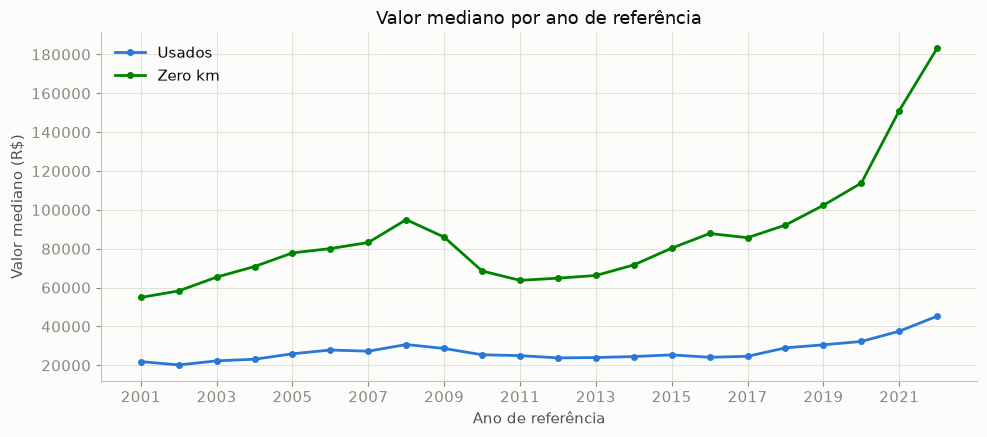

Mediana usados  2001 → 2020 → 2022: [21916, 32295, 45316]
Mediana zero km 2001 → 2020 → 2022: [54932, 113807, 183230]


In [ ]:
VERDE = "#008300"  # segunda cor categórica da paleta

med_ano = df_eda.groupby(["anoReferencia", "zero_km"])["valor"].median().unstack()
med_ano.columns = ["Usados", "Zero km"]

fig, eixo = plt.subplots(figsize=(10, 4.5))
eixo.plot(med_ano.index, med_ano["Usados"],  color=AZUL,  linewidth=2, marker="o", markersize=4, label="Usados")
eixo.plot(med_ano.index, med_ano["Zero km"], color=VERDE, linewidth=2, marker="o", markersize=4, label="Zero km")
eixo.set_title("Valor mediano por ano de referência")
eixo.set_xlabel("Ano de referência")
eixo.set_ylabel("Valor mediano (R$)")
eixo.set_xticks(med_ano.index[::2])
eixo.legend(frameon=False)
plt.tight_layout()
plt.show()

print("Mediana usados  2001 → 2020 → 2022:", [round(med_ano.loc[a, 'Usados'])  for a in (2001, 2020, 2022)])
print("Mediana zero km 2001 → 2020 → 2022:", [round(med_ano.loc[a, 'Zero km']) for a in (2001, 2020, 2022)])


**Interpretação.** As duas curvas contam histórias diferentes:

- **Zero km** (verde): a mediana sobe de ≈ R$ 55 mil (2001) para ≈ R$ 183 mil (2022) — mais que
  triplica em termos nominais, acompanhando inflação, câmbio e a sofisticação crescente dos
  lançamentos.
- **Usados** (azul): a mediana fica surpreendentemente estável, em torno de R$ 20–30 mil, por quase
  duas décadas — o envelhecimento da frota compensa a inflação (a cada ano entram carros mais velhos e
  mais baratos no conjunto). A partir de **2021–2022 a mediana salta ~40%** (R$ 32,3 mil → R$ 45,3
  mil): é o choque da pandemia (escassez de semicondutores, carro novo caro e em falta), que empurrou a
  demanda para os usados.

Duas ressalvas de leitura: o conjunto de modelos acompanhados muda a cada ano (efeito de composição) e
2022 cobre apenas até agosto. Ainda assim, a conclusão central fica clara: **o momento do mercado
(data de referência) desloca os preços**, e por isso será atributo preditivo essencial.


### 4.2 Estudo de caso: o mesmo carro ao longo de 22 anos

Para eliminar o efeito de composição da leitura anterior, acompanhamos **um único veículo** — o Honda
Civic Sedan EX 1997 (`codigoFipe 014009-0`), presente em todos os 260 meses de referência do dataset —
do início ao fim da série.


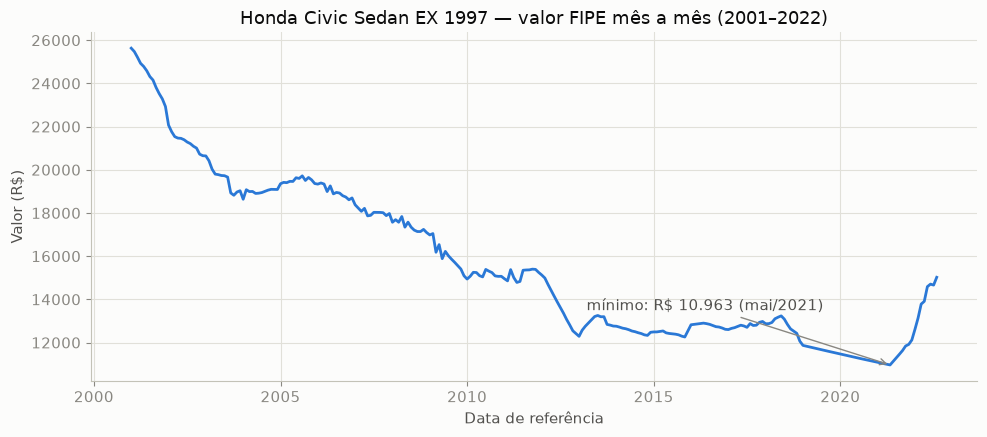

2001 (4 anos de uso):  R$ 25.630
mai/2021 (mínimo):     R$ 10.963
ago/2022 (último mês): R$ 15.021


In [ ]:
civic = df_eda[(df_eda["codigoFipe"] == "014009-0") & (df_eda["anoModelo"] == 1997)].sort_values("dataRef")

fig, eixo = plt.subplots(figsize=(10, 4.5))
eixo.plot(civic["dataRef"], civic["valor"], color=AZUL, linewidth=2)
eixo.set_title("Honda Civic Sedan EX 1997 — valor FIPE mês a mês (2001–2022)")
eixo.set_xlabel("Data de referência")
eixo.set_ylabel("Valor (R$)")

minimo = civic.loc[civic["valor"].idxmin()]
eixo.annotate(f"mínimo: R$ {minimo['valor']:,.0f} (mai/2021)".replace(",", "."),
              xy=(minimo["dataRef"], minimo["valor"]),
              xytext=(2013.2, 13500), color=TINTA_SEC,
              arrowprops=dict(arrowstyle="->", color=CINZA_EIXO))
plt.tight_layout()
plt.show()

print("2001 (4 anos de uso):  R$", f"{civic['valor'].iloc[0]:,.0f}".replace(",", "."))
print("mai/2021 (mínimo):     R$", f"{civic['valor'].min():,.0f}".replace(",", "."))
print("ago/2022 (último mês): R$", f"{civic['valor'].iloc[-1]:,.0f}".replace(",", "."))


**Interpretação.** O mesmo carro físico cai de ≈ R$ 25,6 mil em janeiro de 2001 (quando tinha 4 anos de uso)
até um piso de ≈ R$ 11,0 mil em maio de 2021 — depreciação lenta e quase monotônica por 20 anos. Em
seguida, **sobe 37% em apenas 15 meses** (R$ 15,0 mil em ago/2022), *mesmo envelhecendo*: é o choque
de mercado de 2021–22 visto na seção 4.1, agora sem nenhum efeito de composição.

A lição para a modelagem é direta: o valor de um veículo é função **tanto da idade** (depreciação)
**quanto do momento do mercado** (data de referência). Um modelo que ignore a data de referência não
tem como explicar por que o mesmo Civic de 24 anos valia 37% a mais em 2022 do que em 2021.


### 4.3 Depreciação: valor mediano por idade do veículo

A idade é a contraparte da análise anterior: fixado o momento, quanto o veículo perde de valor ao
envelhecer? Calculamos a mediana do valor por idade (apenas usados, idades de 0 a 25 anos, faixa com
boa quantidade de registros).


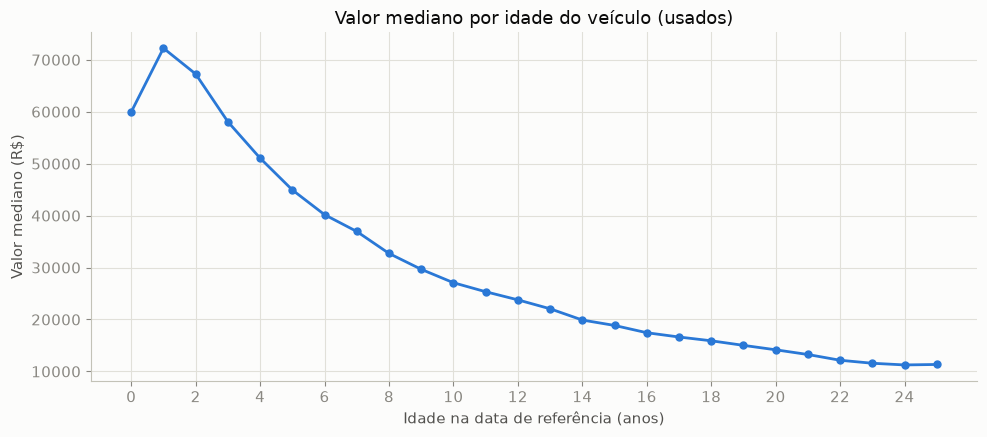

Mediana com 1 ano:  R$ 72.237
Mediana com 5 anos: R$ 44.944 (-38% vs 1 ano)
Mediana com 10 anos:R$ 27.082 (-63% vs 1 ano)
Mediana com 20 anos:R$ 14.169 (-80% vs 1 ano)


In [ ]:
dep = usados[usados["idade"].between(0, 25)].groupby("idade")["valor"].median()

fig, eixo = plt.subplots(figsize=(10, 4.5))
eixo.plot(dep.index, dep.values, color=AZUL, linewidth=2, marker="o", markersize=5)
eixo.set_title("Valor mediano por idade do veículo (usados)")
eixo.set_xlabel("Idade na data de referência (anos)")
eixo.set_ylabel("Valor mediano (R$)")
eixo.set_xticks(range(0, 26, 2))
plt.tight_layout()
plt.show()

print("Mediana com 1 ano:  R$", f"{dep.loc[1]:,.0f}".replace(",", "."))
print("Mediana com 5 anos: R$", f"{dep.loc[5]:,.0f}".replace(",", "."), f"({dep.loc[5]/dep.loc[1]-1:+.0%} vs 1 ano)")
print("Mediana com 10 anos:R$", f"{dep.loc[10]:,.0f}".replace(",", "."), f"({dep.loc[10]/dep.loc[1]-1:+.0%} vs 1 ano)")
print("Mediana com 20 anos:R$", f"{dep.loc[20]:,.0f}".replace(",", "."), f"({dep.loc[20]/dep.loc[1]-1:+.0%} vs 1 ano)")


**Interpretação.** A curva tem o formato clássico de depreciação: partindo do pico com 1 ano de uso
(≈ R$ 72,2 mil), a mediana cai **38% até os 5 anos**, **63% até os 10** e **80% até os 20** — queda
rápida no início e cada vez mais lenta, um decaimento aproximadamente **exponencial** (linear no log).
Isso reforça a transformação logarítmica do alvo e favorece modelos capazes de capturar
não linearidade (árvores), embora uma regressão linear sobre `log(valor)` possa aproximar bem a curva.

O ponto fora do padrão é a idade 0 (≈ R$ 60,0 mil, *abaixo* da idade 1): como a curva agrega carros
diferentes em períodos diferentes, há **efeito de composição** — o conjunto de modelos avaliados com
idade 0 não é o mesmo dos avaliados com idade 1. É um lembrete de que esta curva descreve o mercado em
agregado, não a trajetória de um carro específico (essa foi a seção 4.2).


### 4.4 Marcas: frequência e relação com o alvo

`marca` é o principal atributo categórico de baixa cardinalidade. Verificamos como os registros se
distribuem entre as marcas mais frequentes e quanto o valor varia entre elas.


,registros,% do total,valor mediano (R$)
marca,,,
Renault,44464,9.50,"26,198.00"
Peugeot,41828,9.00,"23,144.00"
Audi,33837,7.30,"80,176.00"
VW - VolksWagen,29838,6.40,"31,006.00"
Ford,26128,5.60,"23,934.00"
Volvo,22296,4.80,"63,087.00"
Mitsubishi,21912,4.70,"50,911.00"
Toyota,20615,4.40,"45,705.00"
Nissan,19009,4.10,"37,138.00"


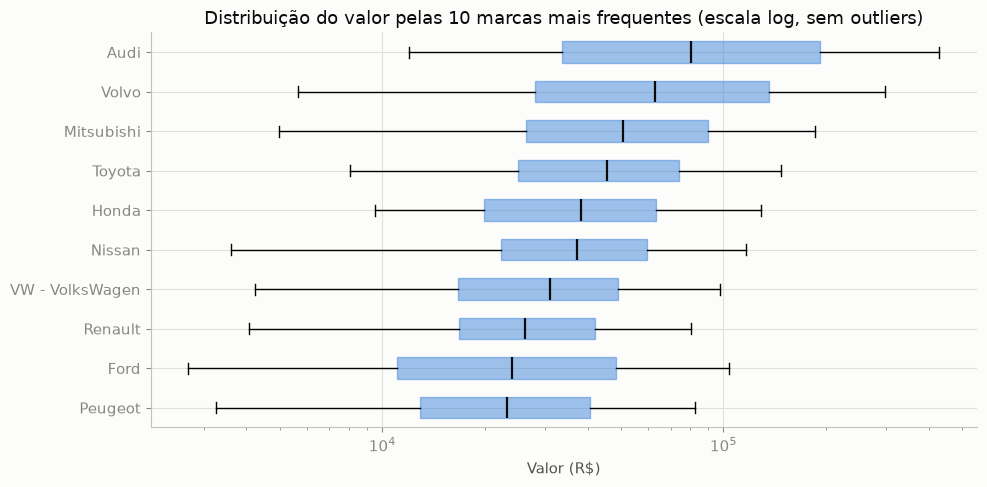

In [ ]:
top10 = df_eda["marca"].value_counts().head(10)
tabela_marcas = pd.DataFrame({
    "registros": top10,
    "% do total": (top10 / len(df_eda) * 100).round(1),
    "valor mediano (R$)": df_eda[df_eda["marca"].isin(top10.index)].groupby("marca")["valor"].median().round(0),
}).sort_values("registros", ascending=False)
display(tabela_marcas)

ordem = df_eda[df_eda["marca"].isin(top10.index)].groupby("marca")["valor"].median().sort_values().index
dados_box = [df_eda.loc[df_eda["marca"] == m, "valor"] for m in ordem]

fig, eixo = plt.subplots(figsize=(10, 5))
caixas = eixo.boxplot(dados_box, orientation="horizontal", tick_labels=list(ordem),
                      patch_artist=True, showfliers=False, widths=0.55,
                      medianprops=dict(color=TINTA, linewidth=1.6))
for caixa in caixas["boxes"]:
    caixa.set(facecolor=AZUL, alpha=0.45, edgecolor=AZUL)
eixo.set_xscale("log")
eixo.set_title("Distribuição do valor pelas 10 marcas mais frequentes (escala log, sem outliers)")
eixo.set_xlabel("Valor (R$)")
plt.tight_layout()
plt.show()


**Interpretação.** A tabela mostra uma concentração moderada: as 10 marcas mais frequentes somam
≈ 59% dos registros, lideradas por Renault (9,5%) e Peugeot (9,0%) — a FIPE acompanha muitas versões
de cada modelo dessas marcas, o que explica a presença forte de fabricantes europeus.

O boxplot (em escala log, ocultando outliers para leitura) mostra que a **mediana varia 3,5× entre
marcas populares e premium**: Peugeot ≈ R$ 23,1 mil e Ford ≈ R$ 23,9 mil contra Audi ≈ R$ 80,2 mil.
Ao mesmo tempo, as caixas são largas e se sobrepõem bastante — dentro de uma mesma marca convivem
carros populares antigos e utilitários novos caros. Conclusão: `marca` **carrega sinal relevante**
(justifica one-hot encoding no pré-processamento), mas está longe de determinar o preço sozinha — o
modelo específico, a idade e a data de referência completam a explicação.


### 4.5 Dispersão idade × valor

O gráfico de dispersão junta as duas peças: cada ponto é um registro (amostra aleatória de 20 mil
usados), com o valor em escala log.


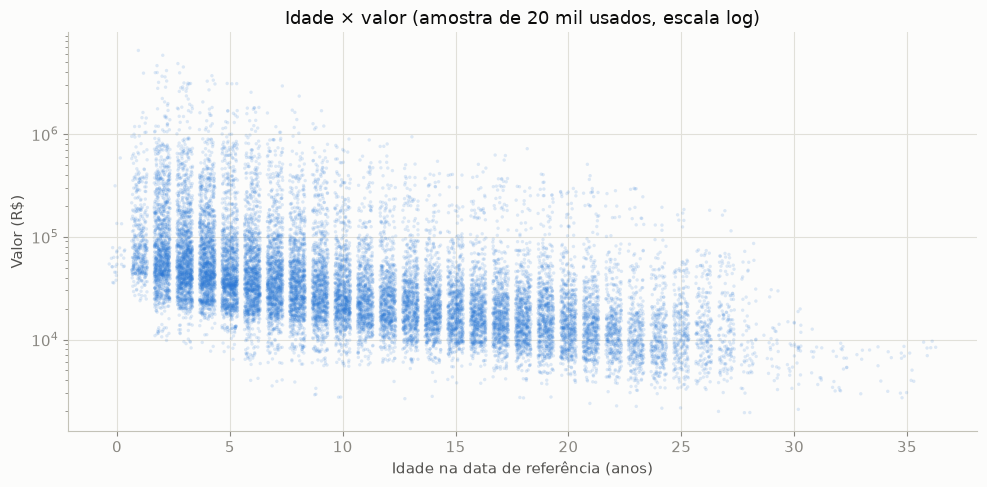

In [ ]:
amostra = usados.sample(20_000, random_state=42)
rng = np.random.default_rng(42)
jitter = rng.uniform(-0.35, 0.35, len(amostra))  # espalha idades inteiras para reduzir sobreposição

fig, eixo = plt.subplots(figsize=(10, 5))
eixo.scatter(amostra["idade"] + jitter, amostra["valor"], s=6, alpha=0.15, color=AZUL, edgecolors="none")
eixo.set_yscale("log")
eixo.set_title("Idade × valor (amostra de 20 mil usados, escala log)")
eixo.set_xlabel("Idade na data de referência (anos)")
eixo.set_ylabel("Valor (R$)")
plt.tight_layout()
plt.show()


**Interpretação.** Na escala log, a nuvem desce de forma aproximadamente **linear com a idade** —
coerente com o decaimento exponencial da seção 4.3 e mais um argumento para modelar `log(valor)`.
Duas características importantes aparecem:

1. **Dispersão vertical enorme em qualquer idade** (de R$ 5 mil a mais de R$ 1 milhão na mesma faixa
   etária): a idade explica a *tendência*, mas o "quem é o carro" (marca/modelo) explica o *nível* —
   um Porsche de 10 anos vale mais que um carro popular zero km.
2. A dispersão é maior nas idades baixas (heterocedasticidade): carros novos vão do popular ao
   superesportivo, enquanto carros de 20+ anos convergem para valores baixos.

Nenhum ponto sugere erro de coleta (não há valores absurdos como R$ 0 ou negativos); a cauda alta são
os veículos de luxo já identificados, que são **legítimos** — por isso não serão removidos como
"outliers", decisão justificada no pré-processamento.


### 4.6 Correlações

Fechamos a análise com a matriz de correlação de Pearson entre o alvo (nas escalas original e log) e
os atributos numéricos — incluindo os derivados `idade` e `zero_km`.


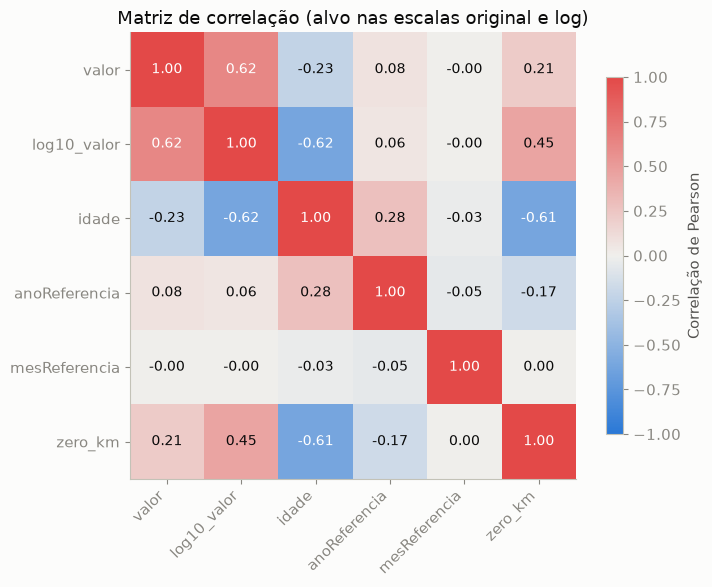

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

colunas_corr = ["valor", "log10_valor", "idade", "anoReferencia", "mesReferencia", "zero_km"]
tmp = df_eda[["valor", "idade", "anoReferencia", "mesReferencia"]].copy()
tmp["log10_valor"] = np.log10(df_eda["valor"])
tmp["zero_km"] = df_eda["zero_km"].astype(int)
corr = tmp[colunas_corr].corr()

cmap_div = LinearSegmentedColormap.from_list("corr", ["#2a78d6", "#f0efec", "#e34948"])
fig, eixo = plt.subplots(figsize=(7.5, 6))
imagem = eixo.imshow(corr, cmap=cmap_div, vmin=-1, vmax=1)
eixo.set_xticks(range(len(colunas_corr)), colunas_corr, rotation=45, ha="right")
eixo.set_yticks(range(len(colunas_corr)), colunas_corr)
eixo.grid(False)
for i in range(len(colunas_corr)):
    for j in range(len(colunas_corr)):
        cor_texto = "white" if abs(corr.iloc[i, j]) > 0.6 else TINTA
        eixo.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color=cor_texto, fontsize=10)
fig.colorbar(imagem, ax=eixo, shrink=0.8, label="Correlação de Pearson")
eixo.set_title("Matriz de correlação (alvo nas escalas original e log)")
plt.tight_layout()
plt.show()


**Interpretação.**

- **`idade` é o atributo numérico mais informativo** — e a escala importa: a correlação com `valor` é
  de apenas −0,23, mas com `log10_valor` chega a **−0,62**. A relação idade–preço é multiplicativa
  (cada ano tira uma *fração* do valor), então ela só aparece linear no log. É o argumento decisivo
  para treinar os modelos lineares sobre o alvo em log.
- **`zero_km`** correlaciona +0,45 com o alvo em log — confirmando que a flag criada a partir da
  inconsistência da seção 3.3 carrega informação real.
- **`anoReferencia`** tem correlação marginal fraca (+0,06 no log), *apesar* de a seção 4.2 mostrar
  que o tempo desloca fortemente os preços. Não há contradição: é o efeito de composição — com o
  passar dos anos a base incorpora carros mais velhos/baratos, mascarando a inflação na correlação
  marginal. O efeito do tempo é real, mas **condicional** ao carro; modelos multivariados conseguem
  capturá-lo, a correlação simples não.
- **`mesReferencia`** é irrelevante (≈ 0,00): o mês dentro do ano quase não move preços; manteremos a
  informação temporal por meio de `anoReferencia`/`dataRef` e avaliaremos descartar o mês isolado.

---

**Síntese da análise exploratória**

| Evidência | Decisão que ela fundamenta |
|---|---|
| Depreciação exponencial (4.3) e nuvem log-linear (4.5) | Alvo em `log` para os modelos lineares; árvores capturam a não linearidade |
| Choque de mercado 2021–22 visível no agregado (4.1) e no carro individual (4.2) | Data de referência entra como atributo preditivo |
| Flag `zero_km` correlacionada ao alvo (4.6) | Manter o tratamento da inconsistência como atributo |
| Mediana varia 3,5× entre marcas, com sobreposição (4.4) | One-hot para `marca`; `modelo` exigirá estratégia própria |
| Cauda de luxo legítima (4.5) | Não remover "outliers" de preço; usar métricas robustas na comparação |
| `mesReferencia` sem correlação (4.6) | Candidato a descarte no pré-processamento |


## 5. Pré-processamento

As seções 3 e 4 identificaram os problemas; aqui aplicamos os tratamentos. Para cada um, seguimos o
mesmo roteiro: **(1) qual problema foi encontrado, (2) qual tratamento foi aplicado, (3) por que esse
tratamento foi escolhido.** Uma regra atravessa toda a seção: transformações que *aprendem* algo dos
dados (imputação, escalonamento, one-hot) são declaradas aqui, mas só serão **ajustadas sobre o
conjunto de treinamento**, dentro de um `Pipeline` — assim nenhuma informação do teste vaza para o
treino.

### 5.1 Limpeza estrutural: coluna irrelevante e duplicatas


In [ ]:
antes = len(df)
df_prep = df.drop(columns=["Unnamed: 0"])

chave = ["codigoFipe", "anoModelo", "mesReferencia", "anoReferencia"]
df_prep = df_prep.drop_duplicates(subset=chave, keep="first").reset_index(drop=True)

print(f"Registros: {antes:,} → {len(df_prep):,}".replace(",", "."))


Registros: 466.020 → 466.018


1. **Problema:** `Unnamed: 0` é um índice sequencial residual da exportação do CSV; e a seção 3.2
   encontrou 2 pares de duplicatas lógicas (mesmo veículo, mesma referência, mesmo valor, grafias
   diferentes de `modelo`).
2. **Tratamento:** descartamos a coluna e removemos 1 linha de cada par duplicado (`keep="first"`),
   usando a chave `codigoFipe + anoModelo + mês + ano`.
3. **Justificativa:** um índice de linha não carrega informação sobre o veículo — mantê-lo poderia
   até induzir um modelo de árvore a "decorar" a ordem do arquivo. As duplicatas têm valores
   idênticos, então qualquer uma pode ser mantida sem perda de informação; removê-las evita dar peso
   dobrado a esses registros.

### 5.2 Correção da inconsistência: `zero_km` e `idade`


In [ ]:
df_prep["zero_km"] = (df_prep["anoModelo"] == 2022).astype(int)
df_prep["idade"] = np.where(df_prep["zero_km"] == 1, 0, df_prep["anoReferencia"] - df_prep["anoModelo"])

# Modelos lançados com ano do modelo seguinte ao da referência têm idade -1; são carros novos → idade 0
negativos = (df_prep["idade"] < 0).sum()
df_prep["idade"] = df_prep["idade"].clip(lower=0)

df_prep = df_prep.drop(columns=["anoModelo"])
print(f"Zero km: {df_prep['zero_km'].sum():,}".replace(",", "."), f"| idades negativas corrigidas: {negativos}")


Zero km: 114.869 | idades negativas corrigidas: 1


1. **Problema:** `anoModelo = 2022` codifica veículo zero km (seção 3.3), o que geraria idades
   negativas absurdas (até −21) se calculássemos `anoReferencia − anoModelo` diretamente; e 1 registro
   legítimo de lançamento (modelo do ano seguinte) tinha idade −1.
2. **Tratamento:** criamos o atributo binário `zero_km`, definimos `idade = 0` para esses veículos
   (e para o lançamento, via `clip`), e **descartamos `anoModelo`**.
3. **Justificativa:** a idade é a variável com significado econômico direto (depreciação, seção 4.3),
   e a flag `zero_km` preserva a distinção real de mercado entre carro novo e usado de idade 0 —
   distinção que a EDA mostrou valer +0,45 de correlação com o alvo em log. Após criar `idade`,
   `anoModelo` fica redundante (`anoModelo = anoReferencia − idade` para usados) e corrompido para os
   zero km — mantê-lo confundiria os modelos. A ambiguidade dos 12.610 registros de 2021–22 (que podem
   ser modelos 2022 usados) fica registrada como limitação do dataset.

### 5.3 Variáveis categóricas de alta cardinalidade: extração de atributos do texto de `modelo`

`marca` (84 categorias) pode virar one-hot, mas `modelo` (5.366) e `codigoFipe` (5.283) não — one-hot
criaria milhares de colunas esparsas. Em vez de descartar toda a informação, extraímos do texto do
modelo dois atributos objetivos: a **cilindrada** (ex.: "1.0", "2.0") e o **câmbio automático**.


In [ ]:
df_prep["cilindrada"] = df_prep["modelo"].str.extract(r"(\d\.\d)", expand=False).astype(float)
df_prep["automatico"] = df_prep["modelo"].str.contains(
    r"Aut\.|AUT\.|A/T|Tiptronic|Multitronic|S[- ]?tronic|CVT", regex=True).astype(int)

cobertura = df_prep["cilindrada"].notna().mean()
print(f"Cilindrada extraída de {cobertura:.1%} dos registros | faixa: "
      f"{df_prep['cilindrada'].min()} a {df_prep['cilindrada'].max()} L")
print(f"Câmbio automático: {df_prep['automatico'].mean():.1%} dos registros")
print("\nExemplos de modelos sem cilindrada no texto:")
print(df_prep.loc[df_prep["cilindrada"].isna(), "modelo"].drop_duplicates().head(5).to_string(index=False))


Cilindrada extraída de 89.1% dos registros | faixa: 0.7 a 6.7 L
Câmbio automático: 26.2% dos registros

Exemplos de modelos sem cilindrada no texto:
164 Super V6 24V
             155
          145 QV
       155 Super
    2300 TI/TI-4


1. **Problema:** `modelo` e `codigoFipe` têm cardinalidade altíssima; usá-los como categorias faria o
   modelo praticamente **decorar cada carro** (um código FIPE identifica o veículo, não o descreve) e
   impediria generalizar para veículos fora da tabela. Descartá-los por completo, porém, jogaria fora
   o que diferencia um Audi A1 de um Audi R8.
2. **Tratamento:** extraímos por expressão regular a `cilindrada` (89,1% de cobertura; faixa plausível
   de 0,7 a 6,7 L; ausente sobretudo em modelos antigos cujo nome não traz o motor, como "155 Super")
   e a flag `automatico` (26,2%). Os 10,9% de cilindrada ausente serão imputados com a **mediana do
   conjunto de treinamento** dentro do pipeline. O texto bruto de `modelo` e o `codigoFipe` saem do
   conjunto de atributos (ficam apenas como metadados para análise de erros).
3. **Justificativa:** os dois atributos têm relação forte e interpretável com o preço — correlação de
   +0,49 entre cilindrada e o alvo em log, e mediana de R$ 75,6 mil (automáticos) contra R$ 30,6 mil
   (manuais). A imputação pela mediana é robusta à assimetria e, feita no pipeline, não vaza
   informação do teste. Alternativas mais sofisticadas (ex.: *target encoding* do `codigoFipe`) ficam
   registradas como melhoria futura.

### 5.4 Atributos temporais


In [ ]:
df_prep["dataRef"] = df_prep["anoReferencia"] + (df_prep["mesReferencia"] - 1) / 12
df_prep = df_prep.drop(columns=["mesReferencia"])
df_prep.head()


,codigoFipe,marca,modelo,anoReferencia,valor,zero_km,idade,cilindrada,automatico,dataRef
0,038003-2,Acura,Integra GS 1.8,2016,"13,041.00",0,24,1.80,0,"2,016.83"
1,038001-6,Acura,NSX 3.0,2013,"52,339.00",0,18,3.00,0,"2,013.17"
2,038003-2,Acura,Integra GS 1.8,2018,"12,423.00",0,26,1.80,0,"2,018.17"
3,038002-4,Acura,Legend 3.2/3.5,2016,"31,067.00",0,18,3.20,0,"2,016.33"
4,038002-4,Acura,Legend 3.2/3.5,2019,"26,381.00",0,21,3.20,0,"2,019.08"


1. **Problema:** a EDA mostrou que o *momento* desloca os preços (seções 4.1–4.2), mas `mesReferencia`
   isolado tem correlação ≈ 0 com o alvo (seção 4.6) — o mês sem o ano é ruído.
2. **Tratamento:** criamos `dataRef`, a data de referência como número contínuo (ex.: julho/2010 →
   2010,5), e descartamos `mesReferencia`. `anoReferencia` permanece no DataFrame **apenas como
   metadado** para análises por período — não entrará como atributo, pois é redundante com `dataRef`.
3. **Justificativa:** uma única variável contínua entrega aos modelos exatamente a informação que
   importa (a posição no tempo, com resolução mensal), evita atributos redundantes/irrelevantes e
   permite à regressão linear capturar a tendência temporal com um único coeficiente.

### 5.5 Escalonamento, codificação e prevenção de vazamento

Definimos agora os atributos finais e o **pré-processador** que será acoplado a cada modelo. Ele ainda
não é ajustado — o `fit` acontecerá somente sobre o conjunto de treinamento, dentro do `Pipeline` de
cada modelo (seções 6 e 7).


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ATRIBUTOS_NUM = ["idade", "cilindrada", "dataRef"]
ATRIBUTOS_BIN = ["zero_km", "automatico"]
ATRIBUTOS_CAT = ["marca"]
ATRIBUTOS = ATRIBUTOS_NUM + ATRIBUTOS_BIN + ATRIBUTOS_CAT
ALVO = "valor"

preprocessador = ColumnTransformer([
    ("num", Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("escalar", StandardScaler()),
    ]), ATRIBUTOS_NUM),
    ("bin", "passthrough", ATRIBUTOS_BIN),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ATRIBUTOS_CAT),
])
preprocessador


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

1. **Problema:** os atributos numéricos têm escalas muito diferentes (idade em anos ~0–37, `dataRef`
   ~2001–2022) — modelos baseados em distância/gradiente e a interpretação de coeficientes lineares
   sofrem com isso; `marca` é texto, que os modelos não consomem diretamente; e `cilindrada` tem 10,9%
   de ausentes. Além disso, qualquer estatística (mediana, média, desvio) calculada sobre o dataset
   completo **vazaria informação do teste**.
2. **Tratamento:** numéricos passam por imputação de mediana + `StandardScaler`; binários passam
   direto (já são 0/1); `marca` vira one-hot com `handle_unknown="ignore"` (uma marca nova no teste
   gera vetor nulo em vez de erro). Tudo dentro de um `ColumnTransformer` acoplado a cada modelo.
3. **Justificativa:** o escalonamento é inócuo para as árvores, mas necessário para a regressão
   linear; o one-hot é viável para 84 categorias e não impõe ordem artificial entre marcas. O ponto
   central é o **vazamento**: como o `fit` do pré-processador ocorre dentro do pipeline, mediana,
   médias e desvios são aprendidos exclusivamente no treino — o teste é transformado com os parâmetros
   do treino, como serão os dados novos em produção.

### 5.6 Valores extremos e transformação do alvo

1. **Problema:** o alvo tem cauda direita extrema (skew 9,9; máximo de R$ 8,4 milhões — seções 3.4 e
   4.5).
2. **Tratamento:** **não removemos** esses registros; em vez disso, os modelos serão treinados sobre
   `log10(valor)`, com as previsões convertidas de volta a reais para o cálculo das métricas (via
   `TransformedTargetRegressor`, seção 7).
3. **Justificativa:** os valores extremos são **veículos de luxo legítimos**, não erros de medição —
   removê-los mudaria o problema ("prever preços, exceto de carros caros"). O log comprime a cauda,
   torna a relação idade–preço aproximadamente linear (evidências das seções 4.3, 4.5 e 4.6) e impede
   que poucos superesportivos dominem o ajuste por mínimos quadrados. Classes desbalanceadas não se
   aplicam (o alvo é contínuo); o desbalanceamento *temporal* (mais registros em anos recentes) não é
   corrigido aqui, mas será considerado na análise de erros.

---

**Síntese do pré-processamento** (mapa: problema → tratamento → justificativa)

| Item do enunciado | O que foi encontrado | Tratamento |
|---|---|---|
| Valores ausentes | Nenhum no dataset original; 10,9% em `cilindrada` (derivada) | Imputação de mediana **no pipeline** (sem vazamento) |
| Variáveis categóricas | `marca` (84) viável; `modelo`/`codigoFipe` (5,3 mil) inviáveis | One-hot para `marca`; extração de `cilindrada`/`automatico`; descarte dos identificadores |
| Escalonamento | Escalas díspares entre numéricos | `StandardScaler` no pipeline (necessário p/ linear, inócuo p/ árvores) |
| Valores extremos | Cauda de luxo legítima (máx. R$ 8,4 mi) | Mantidos; alvo em `log10` |
| Atributos irrelevantes | `Unnamed: 0`, `mesReferencia` isolado, `anoModelo` pós-derivação | Descartados com justificativa |
| Duplicações | 2 pares lógicos | Removida 1 linha de cada par |
| Inconsistências | `anoModelo = 2022` = zero km | Flag `zero_km` + `idade = 0` |
| Classes desbalanceadas | Não se aplica (regressão); desbalanceamento temporal existe | Considerado na análise de erros (seção 8) |


## 6. Separação dos dados

A separação acontece **antes de qualquer ajuste**: nenhuma estatística de treino foi calculada até
aqui (o pré-processador da seção 5.5 foi apenas *declarado*). O protocolo experimental é:

- **80% treino / 20% teste.** Com 466 mil registros, o teste fica com ≈ 93 mil observações — margem
  estatística de sobra para estimar as métricas com precisão. A proporção 80/20 é o ponto de
  equilíbrio usual: mais dados para os modelos aprenderem, sem comprometer a confiabilidade da
  avaliação (com um dataset pequeno essa escolha exigiria mais cuidado; aqui, qualquer fração razoável
  daria estimativas estáveis — 20% é uma escolha conservadora).
- **Estratificação pelo alvo.** Em classificação, estratifica-se pelas classes; em regressão não há
  classes, então discretizamos o alvo em **10 faixas de preço (decis do log do valor)** e
  estratificamos por elas. Isso garante que a cauda de carros de luxo — rara e influente — apareça na
  mesma proporção nos dois conjuntos; um sorteio azarado poderia, por exemplo, concentrar os
  superesportivos no teste.
- **Teste reservado.** O conjunto de teste só será tocado **uma vez**, na avaliação final (seção 8). A
  comparação entre modelos (seção 7) usará **validação cruzada dentro do treino**.
- **`random_state = 42`** fixa o sorteio, tornando o experimento reprodutível.


In [ ]:
from sklearn.model_selection import train_test_split

# Estratificação em regressão: discretizamos o alvo em 10 faixas (decis do log do valor)
faixas_valor = pd.qcut(np.log10(df_prep["valor"]), q=10, labels=False)

treino, teste = train_test_split(df_prep, test_size=0.20, random_state=42, stratify=faixas_valor)

X_treino, y_treino = treino[ATRIBUTOS], treino[ALVO]
X_teste,  y_teste  = teste[ATRIBUTOS],  teste[ALVO]

print(f"Treino: {len(treino):,} registros ({len(treino)/len(df_prep):.0%})".replace(",", "."))
print(f"Teste:  {len(teste):,} registros ({len(teste)/len(df_prep):.0%})".replace(",", "."))


Treino: 372.814 registros (80%)
Teste:  93.204 registros (20%)


In [ ]:
comparacao = pd.DataFrame({"treino": treino["valor"].describe(), "teste": teste["valor"].describe()})
display(comparacao.round(0))

print("Proporção zero km — treino:", f"{treino['zero_km'].mean():.1%}", "| teste:", f"{teste['zero_km'].mean():.1%}")
print("Idade média —        treino:", f"{treino['idade'].mean():.1f}", "| teste:", f"{teste['idade'].mean():.1f}")
print("dataRef mediana —    treino:", f"{treino['dataRef'].median():.2f}", "| teste:", f"{teste['dataRef'].median():.2f}")


,treino,teste
count,"372,814.00","93,204.00"
mean,"115,754.00","115,634.00"
std,"324,244.00","327,640.00"
min,"1,871.00","1,906.00"
25%,"19,389.00","19,387.00"
50%,"39,416.00","39,416.00"
75%,"84,842.00","84,561.00"
max,"8,400,000.00","8,407,082.00"


Proporção zero km — treino: 24.6% | teste: 24.7%
Idade média —        treino: 8.3 | teste: 8.3
dataRef mediana —    treino: 2017.42 | teste: 2017.42


**Interpretação.** As distribuições do alvo nos dois conjuntos são praticamente idênticas em todos os
quantis (mediana, quartis, extremos), e os atributos-chave (proporção de zero km, idade média, centro
temporal) também coincidem — a estratificação funcionou: o teste é um retrato fiel do treino, e as
métricas finais não serão distorcidas por diferença de composição entre os conjuntos.

**Limitação assumida do sorteio aleatório:** como o mesmo veículo aparece em vários meses de
referência, um split aleatório coloca, por exemplo, o Civic de mar/2015 no treino e o de abr/2015 no
teste. Isso torna a avaliação principal um teste de **interpolação** (estimar preços de carros e
períodos que o modelo conheceu), que é coerente com o objetivo da aplicação — reconstruir/estimar
valores dentro da tabela. A capacidade de **extrapolar para meses futuros**, tarefa mais difícil, será
medida separadamente com um corte temporal na seção 8, como teste de robustez.


## 7. Modelagem

Comparamos um **baseline** e os três modelos de regressão trabalhados em sala: **regressão linear**,
**árvore de decisão** e **Random Forest**. Três decisões estruturam o experimento:

- **Baseline.** Um `DummyRegressor` que prevê sempre a **mediana** do treino. Ele define o "custo de
  não modelar nada": qualquer modelo que não o vença com folga não aprendeu coisa alguma.
- **Alvo em log.** Conforme justificado na seção 5.6, cada modelo é embrulhado em um
  `TransformedTargetRegressor`: treina sobre `log10(valor)` e devolve as previsões **já convertidas
  para reais** — as métricas, portanto, são calculadas na escala original, diretamente comparáveis
  entre modelos e interpretáveis em R$.
- **Validação cruzada com 3 folds, só no treino.** Cada fold valida com ≈ 124 mil observações — com
  esse volume, a incerteza das métricas é mínima e mais folds só aumentariam o custo (o Random Forest
  domina o tempo de execução) sem mudar as conclusões. O conjunto de teste continua intocado.

**Parâmetros principais** (mantidos nos padrões da biblioteca, exceto onde indicado):

| Modelo | Parâmetros principais |
|---|---|
| `DummyRegressor` | `strategy="median"` — prevê a mediana do treino, robusta à cauda de luxo |
| `LinearRegression` | padrão: mínimos quadrados ordinários sobre os atributos escalonados |
| `DecisionTreeRegressor` | `random_state=42`; **profundidade livre** (padrão) — risco assumido de sobreajuste, que o Random Forest atenua |
| `RandomForestRegressor` | `n_estimators=100` (padrão), `random_state=42`, `n_jobs=-1` (paraleliza o treino das árvores) |


In [ ]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeRegressor


def exp10(x):
    return np.power(10.0, x)


def em_log(modelo):
    """Treina o modelo sobre log10(valor); as previsões voltam automaticamente em reais."""
    return TransformedTargetRegressor(regressor=modelo, func=np.log10, inverse_func=exp10)


modelos = {
    "Baseline (mediana)": DummyRegressor(strategy="median"),
    "Regressão linear":   em_log(LinearRegression()),
    "Árvore de decisão":  em_log(DecisionTreeRegressor(random_state=42)),
    "Random Forest":      em_log(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
}


⏱️ **Atenção:** a célula abaixo treina os 4 modelos com validação cruzada de 3 folds sobre 373 mil
registros. Em uma máquina com muitos núcleos leva ~10 minutos; no Google Colab gratuito (2 vCPUs)
pode levar bem mais — é o comportamento esperado, não um travamento.


In [ ]:
METRICAS = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R2": "r2"}

resultados = {}
for nome, modelo in modelos.items():
    pipe = Pipeline([("prep", preprocessador), ("modelo", modelo)])
    cv = cross_validate(pipe, X_treino, y_treino, cv=3, scoring=METRICAS)
    resultados[nome] = {
        "MAE (R$)":  -cv["test_MAE"].mean(),
        "RMSE (R$)": -cv["test_RMSE"].mean(),
        "R²":         cv["test_R2"].mean(),
        "R² (desvio entre folds)": cv["test_R2"].std(),
        "tempo de treino (s)": cv["fit_time"].mean(),
    }
    print(f"✔ {nome}")

tabela_cv = pd.DataFrame(resultados).T
tabela_cv.style.format({"MAE (R$)": "{:,.0f}", "RMSE (R$)": "{:,.0f}", "R²": "{:.3f}",
                        "R² (desvio entre folds)": "{:.4f}", "tempo de treino (s)": "{:.0f}"})


✔ Baseline (mediana)


✔ Regressão linear


✔ Árvore de decisão


✔ Random Forest


,MAE (R$),RMSE (R$),R²,R² (desvio entre folds),tempo de treino (s)
Baseline (mediana),"95,332","333,084",-0.055,0.0015,0
Regressão linear,"36,023","153,514",0.776,0.0021,2
Árvore de decisão,"18,971","97,179",0.910,0.0007,28
Random Forest,"17,738","87,782",0.927,0.0012,186


**Interpretação e comparação.**

- **Todos os modelos vencem o baseline com folga** — prever sempre a mediana erra R$ 95,3 mil na
  média. Curiosidade instrutiva: o R² do baseline é *negativo* (≈ −0,06). O R² compara o modelo com
  quem prevê sempre a **média**; como a distribuição é assimétrica, a mediana perde da média no erro
  quadrático — exatamente o comportamento esperado, e um lembrete de que o baseline de mediana otimiza
  o MAE, não o RMSE.
- **Regressão linear (MAE ≈ R$ 36,0 mil; R² 0,78):** corta o erro do baseline em ~62%, confirmando que
  os atributos carregam muito sinal. Mas o modelo é limitado por construção: com um único coeficiente
  por atributo, não consegue representar interações — por exemplo, "um ano a mais deprecia um carro de
  luxo em mais reais do que um popular".
- **Árvore de decisão (MAE ≈ R$ 19,0 mil; R² 0,91):** corta o erro da linear **quase pela metade**,
  exatamente por capturar não linearidades e interações entre idade, tempo, marca e cilindrada. O
  risco da profundidade livre é o sobreajuste — a validação cruzada é o que garante que esse ganho é
  real e não memorização.
- **Random Forest (MAE ≈ R$ 17,7 mil; R² 0,93):** melhora a árvore em mais 6,5% no MAE e 9,7% no RMSE.
  O ganho maior justamente no RMSE é coerente com a teoria: a média de 100 árvores aleatorizadas reduz
  a **variância** da árvore única, e variância menor pesa mais na métrica quadrática.
- **Estabilidade:** o desvio do R² entre folds é ≤ 0,002 em todos os modelos — com 124 mil observações
  por fold de validação, os resultados são estáveis; a ordem dos modelos não é obra do acaso.

**Escolha do modelo final: Random Forest.** É o melhor nas três métricas, com folga sobre a regressão
linear e ganho consistente sobre a árvore única; o custo extra de treino (~3 minutos por fold nesta
máquina) é irrelevante para a aplicação. A árvore única ficaria como alternativa se a prioridade fosse
interpretabilidade ou custo mínimo; a regressão linear, apesar do R² 0,78, erra demais na escala de
preços de carros para ser útil como estimador da tabela.


## 8. Avaliação final e discussão

### 8.1 Treino final e avaliação única no conjunto de teste

O Random Forest é treinado agora sobre **todo o conjunto de treinamento** e avaliado no conjunto de
teste — que é tocado aqui **pela primeira e única vez**. Além de MAE, RMSE e R², acrescentamos duas
métricas justificadas pelo problema: o **MAPE** (erro percentual médio — mais justo para comparar o
erro em um Gol e em uma Ferrari) e a **mediana do erro absoluto** (MedAE — o erro "típico", imune à
cauda de luxo).


In [ ]:
from sklearn.metrics import (mean_absolute_error, mean_absolute_percentage_error,
                             median_absolute_error, r2_score, root_mean_squared_error)

modelo_final = Pipeline([("prep", preprocessador), ("modelo", modelos["Random Forest"])])
modelo_final.fit(X_treino, y_treino)
pred_teste = modelo_final.predict(X_teste)

metricas_teste = pd.Series({
    "MAE (R$)":   mean_absolute_error(y_teste, pred_teste),
    "RMSE (R$)":  root_mean_squared_error(y_teste, pred_teste),
    "MedAE (R$)": median_absolute_error(y_teste, pred_teste),
    "MAPE":       mean_absolute_percentage_error(y_teste, pred_teste),
    "R²":         r2_score(y_teste, pred_teste),
}, name="Random Forest — teste")
metricas_teste.to_frame().style.format("{:,.4f}")


,Random Forest — teste
MAE (R$),"17,117.7009"
RMSE (R$),"84,545.3866"
MedAE (R$),"2,372.7650"
MAPE,0.1291
R²,0.9334


**Interpretação.**

- **Teste ≈ validação cruzada:** MAE de R$ 17,1 mil no teste contra R$ 17,7 mil na CV (RMSE 84,5 mil
  vs 87,8 mil; R² 0,933 vs 0,927). A avaliação final **confirma** a estimativa da validação — não
  houve sobreajuste ao protocolo de comparação, e o desempenho reportado é confiável.
- **O erro típico é muito menor que o MAE:** metade das previsões erra **menos de R$ 2,4 mil**
  (MedAE). O MAE de R$ 17,1 mil é inflado pela cauda de luxo — errar R$ 500 mil em uma Ferrari pesa o
  mesmo que errar R$ 500 em mil carros populares.
- **MAPE de 12,9%:** em termos relativos, o modelo erra em média ~13% do valor do carro — para uma
  tabela de referência de preços, é um erro na ordem da variação entre um carro bem e mal conservado.

### 8.2 Previsto × real


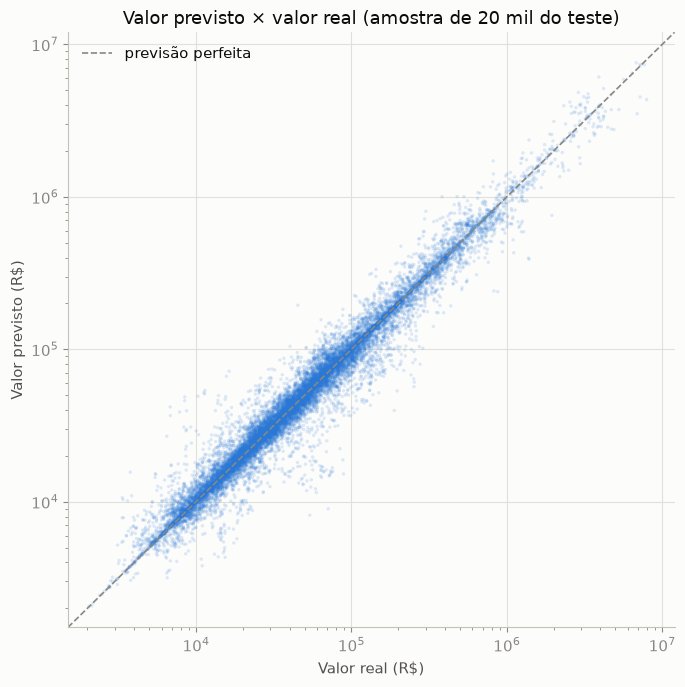

In [ ]:
amostra_teste = teste.sample(20_000, random_state=42)
pred_amostra = modelo_final.predict(amostra_teste[ATRIBUTOS])

fig, eixo = plt.subplots(figsize=(7, 7))
eixo.scatter(amostra_teste["valor"], pred_amostra, s=6, alpha=0.15, color=AZUL, edgecolors="none")
limites = [1.5e3, 1.2e7]
eixo.plot(limites, limites, color=CINZA_EIXO, linewidth=1.2, linestyle="--", label="previsão perfeita")
eixo.set_xscale("log"); eixo.set_yscale("log")
eixo.set_xlim(limites); eixo.set_ylim(limites)
eixo.set_title("Valor previsto × valor real (amostra de 20 mil do teste)")
eixo.set_xlabel("Valor real (R$)")
eixo.set_ylabel("Valor previsto (R$)")
eixo.legend(frameon=False)
plt.tight_layout()
plt.show()


**Interpretação.** A nuvem se concentra sobre a diagonal em **quatro ordens de grandeza** — de carros
de R$ 5 mil a superesportivos de milhões — sinal de que o alvo em log fez o modelo tratar todas as
faixas com atenção proporcional. A dispersão é visivelmente maior nas pontas: nos carros muito baratos
(estado de conservação heterogêneo) e nos muito caros (pouquíssimos exemplares para aprender), o que a
análise a seguir quantifica.

### 8.3 Onde o modelo erra


In [ ]:
avaliacao = teste.copy()
avaliacao["pred"] = pred_teste
avaliacao["erro_abs"] = (avaliacao["pred"] - avaliacao["valor"]).abs()
avaliacao["erro_pct"] = avaliacao["erro_abs"] / avaliacao["valor"]

por_preco = avaliacao.groupby(pd.qcut(avaliacao["valor"], q=10), observed=True).agg(
    **{"MAE (R$)": ("erro_abs", "mean"), "MAPE": ("erro_pct", "mean"), "registros": ("valor", "size")})
por_preco.index.name = "faixa de valor real (decis)"
display(por_preco.style.format({"MAE (R$)": "{:,.0f}", "MAPE": "{:.1%}", "registros": "{:,.0f}"}))

por_idade = avaliacao.groupby(pd.cut(avaliacao["idade"], [-1, 0, 5, 10, 20, 40],
                                     labels=["0 (zero km)", "1-5", "6-10", "11-20", "21+"]), observed=True).agg(
    **{"MAE (R$)": ("erro_abs", "mean"), "MAPE": ("erro_pct", "mean"), "registros": ("valor", "size")})
por_idade.index.name = "idade (anos)"
display(por_idade.style.format({"MAE (R$)": "{:,.0f}", "MAPE": "{:.1%}", "registros": "{:,.0f}"}))

por_periodo = avaliacao.groupby(pd.cut(avaliacao["anoReferencia"], [2000, 2005, 2010, 2015, 2020, 2022],
                                       labels=["2001-05", "2006-10", "2011-15", "2016-20", "2021-22"]), observed=True).agg(
    **{"MAE (R$)": ("erro_abs", "mean"), "MAPE": ("erro_pct", "mean"), "registros": ("valor", "size")})
por_periodo.index.name = "período de referência"
display(por_periodo.style.format({"MAE (R$)": "{:,.0f}", "MAPE": "{:.1%}", "registros": "{:,.0f}"}))


,MAE (R$),MAPE,registros
faixa de valor real (decis),,,
"(1905.999, 11248.0]","1,300",17.0%,"9,323"
"(11248.0, 16536.0]","1,816",13.1%,"9,319"
"(16536.0, 22620.0]","2,016",10.3%,"9,320"
"(22620.0, 30041.6]","2,969",11.4%,"9,320"
"(30041.6, 39416.0]","3,445",10.0%,"9,321"
"(39416.0, 51785.8]","5,151",11.3%,"9,319"
"(51785.8, 70428.7]","8,095",13.3%,"9,321"
"(70428.7, 107801.4]","11,423",13.3%,"9,320"
"(107801.4, 233795.2]","22,202",14.3%,"9,320"


,MAE (R$),MAPE,registros
idade (anos),,,
0 (zero km),"41,993",14.9%,"23,080"
1-5,"17,691",10.9%,"19,411"
6-10,"8,673",11.1%,"18,155"
11-20,"3,950",12.2%,"24,179"
21+,"3,567",18.3%,"8,379"


,MAE (R$),MAPE,registros
período de referência,,,
2001-05,"12,150",14.0%,"8,143"
2006-10,"11,040",12.2%,"12,516"
2011-15,"13,525",12.1%,"18,019"
2016-20,"17,538",12.7%,"37,685"
2021-22,"26,941",14.3%,"16,841"


In [ ]:
piores = avaliacao.nlargest(10, "erro_abs")[
    ["marca", "modelo", "idade", "anoReferencia", "valor", "pred", "erro_pct"]]
piores.style.format({"valor": "R$ {:,.0f}", "pred": "R$ {:,.0f}", "erro_pct": "{:.0%}"}).hide(axis="index")


marca,modelo,idade,anoReferencia,valor,pred,erro_pct
Mercedes-Benz,GT AMG BLACK SERIES 4.0 V8 Bi-Turbo,0,2022,"R$ 5,980,566","R$ 1,377,822",77%
LAMBORGHINI,AVENTADOR LP 770-4 SVJ,0,2021,"R$ 7,200,000","R$ 3,347,320",54%
LAMBORGHINI,AVENTADOR LP 770-4 SVJ,0,2020,"R$ 6,900,000","R$ 3,084,687",55%
LAMBORGHINI,AVENTADOR 770-4 SVJ ROADSTER V12,0,2021,"R$ 8,228,142","R$ 4,491,173",45%
LAMBORGHINI,AVENTADOR LP 770-4 SVJ,0,2021,"R$ 7,200,000","R$ 3,562,695",51%
LAMBORGHINI,AVENTADOR LP 770-4 SVJ,0,2020,"R$ 6,900,000","R$ 3,285,228",52%
LAMBORGHINI,AVENTADOR 770-4 SVJ ROADSTER V12,0,2021,"R$ 7,941,273","R$ 4,347,264",45%
LAMBORGHINI,AVENTADOR LP 770-4 SVJ,0,2020,"R$ 6,900,000","R$ 3,508,594",49%
LAMBORGHINI,AVENTADOR LP 770-4 SVJ,0,2021,"R$ 7,200,347","R$ 3,815,147",47%
Mclaren,765LT Coupe 4.0 Bi-Turbo V8,0,2021,"R$ 6,600,000","R$ 3,651,463",45%


**Interpretação das três quebras e dos piores casos.**

- **Por faixa de preço:** o MAE cresce com o valor (R$ 1,3 mil no decil mais barato → R$ 113 mil no
  mais caro), mas isso é o esperado — o que importa é o **MAPE, que fica entre 10% e 17% em todos os
  decis**: o alvo em log distribuiu o esforço do modelo de forma equilibrada. Os dois piores decis em
  termos relativos são os **extremos**: os carros mais baratos (17,0% — veículos antigos, cujo valor
  depende de conservação que os dados não registram) e os mais caros (15,1%).
- **Por idade:** o menor MAPE está nos carros de 1–5 anos (10,9%), justamente a faixa mais líquida do
  mercado; o pior está nos 21+ anos (18,3%), onde o estado de conservação domina o preço.
- **Por período:** 2021–22 é o período mais difícil (MAE R$ 26,9 mil), coerente com o choque de
  preços — o mercado ficou genuinamente mais volátil.
- **Piores erros individuais:** a lista é inteira de **superesportivos zero km** — Lamborghini
  Aventador SVJ, Mercedes-AMG GT Black Series, McLaren 765LT — subestimados em 50–77%. O caso do AMG
  Black Series resume o limite do modelo: para ele, aquilo é "um Mercedes 4.0 automático zero km"
  (previsto R$ 1,4 mi), pois nenhum atributo informa que é uma edição limitada de R$ 6 mi. São
  pouquíssimos exemplares e os atributos disponíveis não os distinguem — limitação de representação,
  não de algoritmo.

### 8.4 Importância dos atributos


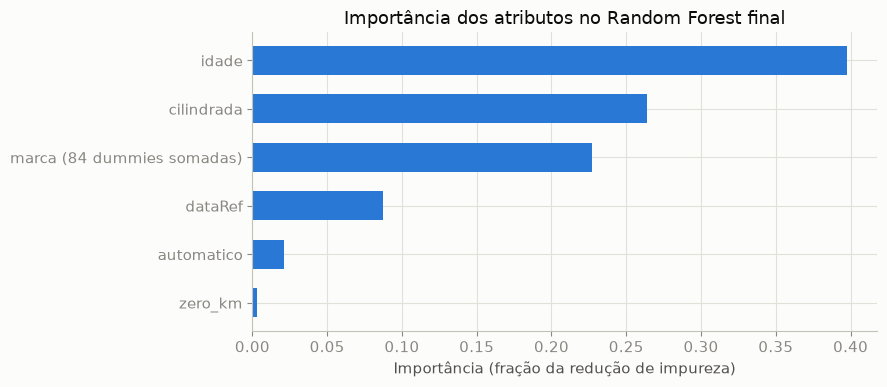

Marcas com maior importância individual:
cat__marca_Ferrari       0.07
cat__marca_Porsche       0.04
cat__marca_LAMBORGHINI   0.02


In [ ]:
rf_ajustado = modelo_final.named_steps["modelo"].regressor_
nomes_atributos = modelo_final.named_steps["prep"].get_feature_names_out()
importancias = pd.Series(rf_ajustado.feature_importances_, index=nomes_atributos)

resumo_imp = pd.Series({
    "idade":       importancias["num__idade"],
    "cilindrada":  importancias["num__cilindrada"],
    "marca (84 dummies somadas)": importancias[[c for c in importancias.index if c.startswith("cat__")]].sum(),
    "dataRef":     importancias["num__dataRef"],
    "automatico":  importancias["bin__automatico"],
    "zero_km":     importancias["bin__zero_km"],
}).sort_values()

fig, eixo = plt.subplots(figsize=(9, 4))
eixo.barh(resumo_imp.index, resumo_imp.values, height=0.6, color=AZUL)
eixo.set_title("Importância dos atributos no Random Forest final")
eixo.set_xlabel("Importância (fração da redução de impureza)")
plt.tight_layout()
plt.show()

print("Marcas com maior importância individual:")
print(importancias[[c for c in importancias.index if c.startswith("cat__")]]
      .sort_values(ascending=False).head(3).round(3).to_string())


**Interpretação.** O ranking confirma a análise exploratória: **idade (40%)** e **cilindrada (26%)**
dominam, seguidas do conjunto de marcas (23% — com Ferrari sozinha valendo 7%: para a floresta,
saber que o carro é uma Ferrari reposiciona o preço em outra ordem de grandeza) e da **data de
referência (8,7%)** — a prova quantitativa de que o tempo importa, como a EDA indicava. `zero_km`
aparece com importância mínima não por ser inútil, mas por ser **redundante com `idade = 0`**: a
floresta obtém quase a mesma informação da idade — as importâncias medem contribuição *marginal*, e
atributos correlacionados dividem o crédito.

### 8.5 Robustez temporal: e se o modelo tivesse que prever o futuro?

A avaliação principal (split aleatório) mede **interpolação**. Aqui rodamos o teste mais duro
prometido na seção 6: treinar só com referências **até 2020** e prever **2021–22** — simulando o uso
do modelo para estimar meses que ainda não existiam.


In [ ]:
treino_temporal = df_prep[df_prep["anoReferencia"] <= 2020]
teste_temporal  = df_prep[df_prep["anoReferencia"] >= 2021]

from sklearn.base import clone
modelo_temporal = clone(modelo_final)
modelo_temporal.fit(treino_temporal[ATRIBUTOS], treino_temporal[ALVO])
pred_temporal = modelo_temporal.predict(teste_temporal[ATRIBUTOS])

comparativo = pd.DataFrame({
    "Split aleatório (interpolação)": metricas_teste,
    "Corte temporal (extrapolação)": {
        "MAE (R$)":   mean_absolute_error(teste_temporal[ALVO], pred_temporal),
        "RMSE (R$)":  root_mean_squared_error(teste_temporal[ALVO], pred_temporal),
        "MedAE (R$)": median_absolute_error(teste_temporal[ALVO], pred_temporal),
        "MAPE":       mean_absolute_percentage_error(teste_temporal[ALVO], pred_temporal),
        "R²":         r2_score(teste_temporal[ALVO], pred_temporal),
    },
})
display(comparativo.style.format("{:,.4f}"))

vies_pct = ((pred_temporal - teste_temporal[ALVO]) / teste_temporal[ALVO]).mean()
print(f"Viés médio percentual do corte temporal (previsto − real): {vies_pct:+.1%}")


,Split aleatório (interpolação),Corte temporal (extrapolação)
MAE (R$),"17,117.7009","54,970.1066"
RMSE (R$),"84,545.3866","207,550.0815"
MedAE (R$),"2,372.7650","11,476.3003"
MAPE,0.1291,0.2884
R²,0.9334,0.8172


Viés médio percentual do corte temporal (previsto − real): -20.4%


**Interpretação.** A degradação é grande e **instrutiva**: o MAE mais que triplica (R$ 17,1 mil →
R$ 55,0 mil), o MAPE vai de 12,9% para 28,8%, e o viés médio de **−20,4%** revela o mecanismo: o
modelo **subestima sistematicamente** os preços de 2021–22. Dois motivos se somam:

1. o modelo nunca viu o choque de preços da pandemia (seções 4.1–4.2) — nenhum modelo baseado em
   dados até 2020 poderia antecipá-lo;
2. árvores e florestas **não extrapolam**: uma previsão de Random Forest é uma média de valores das
   folhas, limitada ao intervalo visto no treino. Para `dataRef` além de 2020, o modelo responde como
   se fosse 2020 — a tendência não continua.

A conclusão honesta sobre o escopo de uso: o modelo é confiável para **estimar valores dentro do
período coberto pela tabela** (o objetivo declarado na seção 1); para prever meses futuros seria
necessária outra formulação (modelos de tendência/série temporal, correção de inflação, retreino
mensal).

### 8.6 Discussão final

**Qual modelo venceu e por quê.** O **Random Forest** foi o melhor nas três métricas da validação
cruzada (MAE R$ 17,7 mil; RMSE R$ 87,8 mil; R² 0,927) e confirmou no teste (MAE R$ 17,1 mil; R²
0,933). A progressão conta a história: a regressão linear (R² 0,78) prova que os atributos têm sinal,
mas não representa interações; a árvore única (R² 0,91) captura as não linearidades; a floresta reduz
a variância da árvore e fica com o melhor dos dois mundos. O custo extra de treino (~3 min) é
irrelevante para a aplicação.

**Erros observados.** (1) Superesportivos zero km subestimados em até 77% — pouquíssimos exemplares e
atributos que não distinguem edições limitadas; (2) MAPE mais alto nos carros muito antigos/baratos,
cujo preço depende de conservação não observada; (3) período 2021–22 mais difícil por volatilidade
genuína do mercado.

**Limitações.**

1. **Atributos ausentes:** quilometragem, estado de conservação, cor, região — variáveis que movem
   preço real e não existem na tabela FIPE;
2. **Ambiguidade da fonte:** `anoModelo = 2022` mistura zero km com possíveis modelos 2022 usados nas
   referências de 2021–22 (12,6 mil registros);
3. **Preços nominais:** sem correção de inflação, parte do que o modelo aprende via `dataRef` é
   simplesmente o nível geral de preços;
4. **Avaliação principal mede interpolação** — o split aleatório coloca o mesmo carro em meses
   vizinhos nos dois conjuntos; a extrapolação temporal, medida à parte, é muito pior;
5. **Identidade fina do veículo descartada:** sem `codigoFipe` como atributo, versões de luxo da mesma
   marca/cilindrada são indistinguíveis.

**O que poderia ser melhorado.** *Target encoding* do `codigoFipe` (codificação por média do alvo no
treino, controlando vazamento) para recuperar a identidade fina; correção dos valores pelo IPCA antes
da modelagem; *gradient boosting* (HistGradientBoostingRegressor/XGBoost), tipicamente superior ao
Random Forest em tabulares; busca de hiperparâmetros (`RandomizedSearchCV`); validação temporal
deslizante e retreino mensal para uso em produção; e extração de mais atributos do texto do modelo
(diesel, turbo, número de portas, versão esportiva).
